# DGP walkthrough: building the synthetic geo panels from scratch

This notebook writes out the data-generating process (DGP) behind the study's synthetic
panels **by hand, one piece at a time** — no imports from `src/`. The goal is to let you
read, tweak, and re-run each component (geo baselines, trend, seasonality, AR(1) noise,
treatment effect) and see exactly how it shapes the final panel, before combining
everything into the study's four stress-test scenarios.

Why simulate at all? Because we need to know the **true** treatment effect to evaluate
whether each geo-experiment tool (GeoLift, CausalPy, Google Matched Markets,
CausalImpact) recovers it — something you can never know with certainty from real data.

This is a from-scratch teaching copy. The reusable, imported version of this same DGP
lives in `src/python/panel_dgp.py` (used by `tool_comparison_walkthrough.ipynb`), and the
canonical version that produced the study's committed results is the R script
`src/R/generate_panels.R`. All three implement the same statistical structure.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 1
N_GEOS = 21          # 1 treated + 20 control, the default panel size
BASELINE_MEAN = 4000
BASELINE_SPREAD = 0.6
TOTAL_DAYS = 105
PRE_DAYS = 90
TREND_SLOPE = 0.001
SEASONALITY_AMPLITUDE = 0.10
DOW_PROFILE = [-1.0, -0.5, 0.0, 0.2, 0.8, 1.0, 0.5]  # Mon..Sun
AUTOCORRELATION = 0.30
NOISE_LEVEL = 0.20
EFFECT_PCT = 0.075

## 1. Geo baselines

Each geo gets a baseline daily volume drawn from a **log-normal distribution**. We pick
the `meanlog` parameter so the distribution's mean works out to `BASELINE_MEAN`
(4000), then sort the draws ascending and name them "City 1" (smallest) through
"City N" (largest).

mean baseline: 3602  (target: 4000)


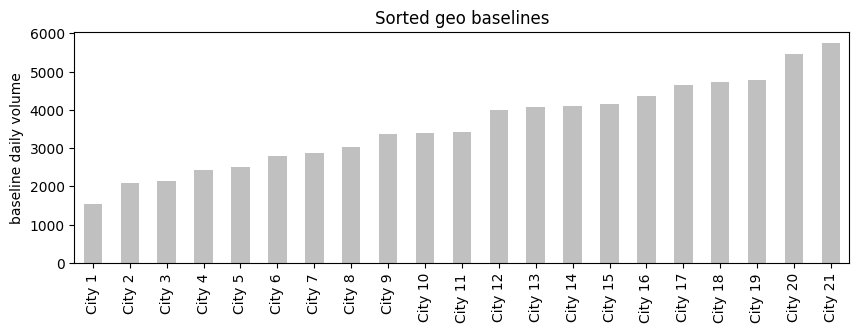

In [2]:
rng = np.random.default_rng(SEED)

meanlog = np.log(BASELINE_MEAN) - BASELINE_SPREAD**2 / 2
baselines = rng.lognormal(mean=meanlog, sigma=BASELINE_SPREAD, size=N_GEOS)
baselines = np.sort(baselines)
geo_names = [f"City {i + 1}" for i in range(N_GEOS)]
baselines = pd.Series(baselines, index=geo_names)

print(f"mean baseline: {baselines.mean():.0f}  (target: {BASELINE_MEAN})")
baselines.plot(kind="bar", figsize=(10, 3), color="#c0c0c0", title="Sorted geo baselines")
plt.ylabel("baseline daily volume")
plt.show()

## 2. Selecting the treated geo

The treated geo is not picked randomly — it's chosen as whichever geo sits **closest to
the median baseline**, so the treated unit is a "typical" geo rather than an extreme
outlier by default.

median baseline: 3422
treated geo: City 11 (baseline 3422)


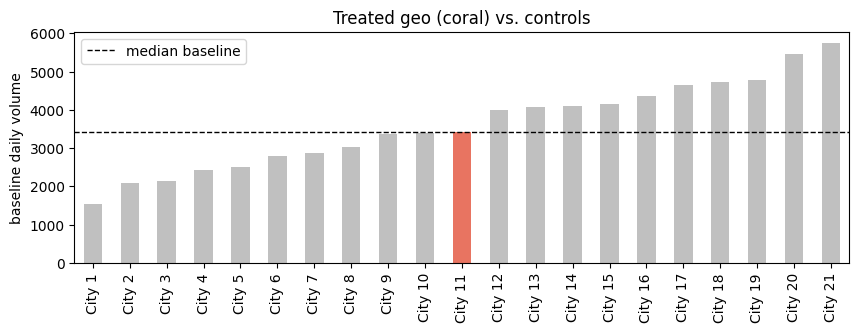

In [3]:
median_val = baselines.median()
diffs = (baselines - median_val).abs()
treated_name = diffs.sort_values(kind="stable").index[0]
treated_idx = baselines.index.get_loc(treated_name)

print(f"median baseline: {median_val:.0f}")
print(f"treated geo: {treated_name} (baseline {baselines[treated_name]:.0f})")

colors = ["#E87461" if g == treated_name else "#c0c0c0" for g in baselines.index]
baselines.plot(kind="bar", figsize=(10, 3), color=colors, title="Treated geo (coral) vs. controls")
plt.axhline(median_val, color="black", linestyle="--", linewidth=1, label="median baseline")
plt.ylabel("baseline daily volume")
plt.legend()
plt.show()

## 3. Trend component

A shared linear growth trend, applied identically to every geo: `trend_t = 1 + slope * t`.
With `slope = 0.001`, volume drifts up ~10% in level over the full 105-day window.

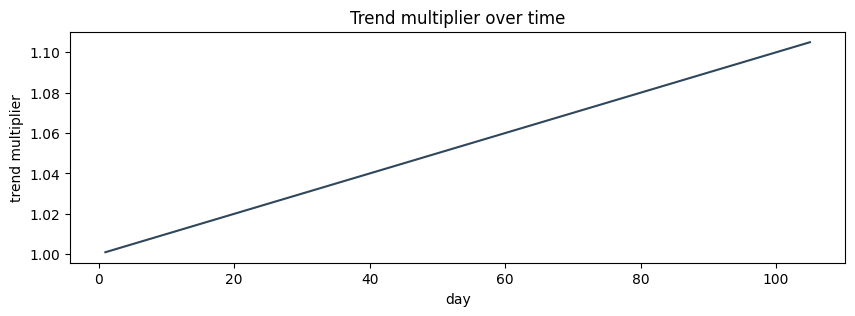

In [4]:
t_seq = np.arange(1, TOTAL_DAYS + 1)
trend = 1 + TREND_SLOPE * t_seq

plt.figure(figsize=(10, 3))
plt.plot(t_seq, trend, color="#2f465b")
plt.title("Trend multiplier over time")
plt.xlabel("day")
plt.ylabel("trend multiplier")
plt.show()

## 4. Weekly seasonality

A fixed day-of-week profile (Mon..Sun), scaled by `SEASONALITY_AMPLITUDE` (10%). Monday
is the low point, Friday/Saturday the high points — a rough proxy for weekly demand
cycles.

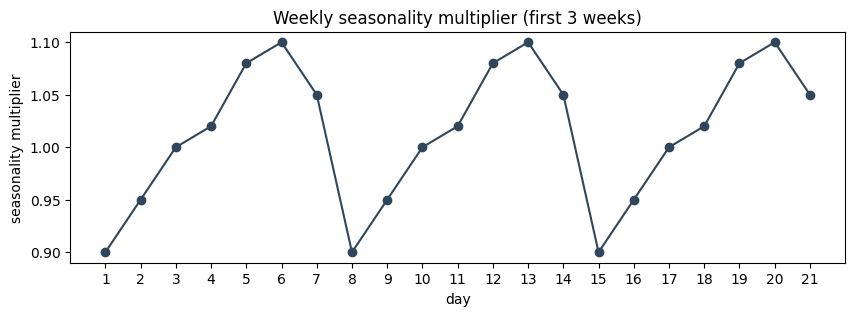

In [5]:
dow_idx = (t_seq - 1) % 7
season = 1 + SEASONALITY_AMPLITUDE * np.array(DOW_PROFILE)[dow_idx]

plt.figure(figsize=(10, 3))
plt.plot(t_seq[:21], season[:21], marker="o", color="#2f465b")
plt.title("Weekly seasonality multiplier (first 3 weeks)")
plt.xlabel("day")
plt.ylabel("seasonality multiplier")
plt.xticks(t_seq[:21])
plt.show()

## 5. AR(1) noise

Each geo gets its own autocorrelated noise path:

```
noise[t] = autocorrelation * noise[t-1] + innovation[t]
```

This makes noise "sticky" day-to-day rather than independent. The noise is then scaled
per geo by `scale_i = sqrt(baseline_i / mean(baseline))` — bigger geos get *larger*
absolute noise amplitude (consistent with aggregating more underlying units), even
though the noise is applied multiplicatively (so relative noise still shrinks a bit for
very large geos, similar to Poisson-like scaling).

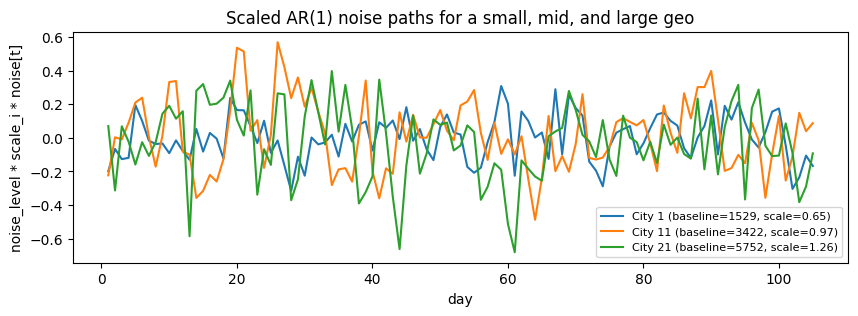

In [6]:
def ar1_noise(total_days, autocorrelation, seed):
    local_rng = np.random.default_rng(seed)
    innovations = local_rng.standard_normal(total_days)
    noise = np.empty(total_days)
    noise[0] = innovations[0]
    for t in range(1, total_days):
        noise[t] = autocorrelation * noise[t - 1] + innovations[t]
    return noise

mean_baseline = baselines.mean()
example_geos = [baselines.index[0], baselines.index[N_GEOS // 2], baselines.index[-1]]

plt.figure(figsize=(10, 3))
for i, geo in enumerate(example_geos):
    noise = ar1_noise(TOTAL_DAYS, AUTOCORRELATION, seed=SEED + 100_000 + i)
    scale_i = np.sqrt(baselines[geo] / mean_baseline)
    plt.plot(t_seq, NOISE_LEVEL * scale_i * noise, label=f"{geo} (baseline={baselines[geo]:.0f}, scale={scale_i:.2f})")
plt.title("Scaled AR(1) noise paths for a small, mid, and large geo")
plt.xlabel("day")
plt.ylabel("noise_level * scale_i * noise[t]")
plt.legend(fontsize=8)
plt.show()

## 6. Combine into the counterfactual outcome

Putting the pieces together, the untreated (counterfactual) outcome for geo `i` at day
`t` is:

```
Y_cf[i, t] = baseline_i * trend_t * season_t * exp(noise_level * scale_i * ar_noise[i, t])
```

All four components are multiplicative, so a geo's series is a scaled, noisy version of
the shared trend/seasonality shape.

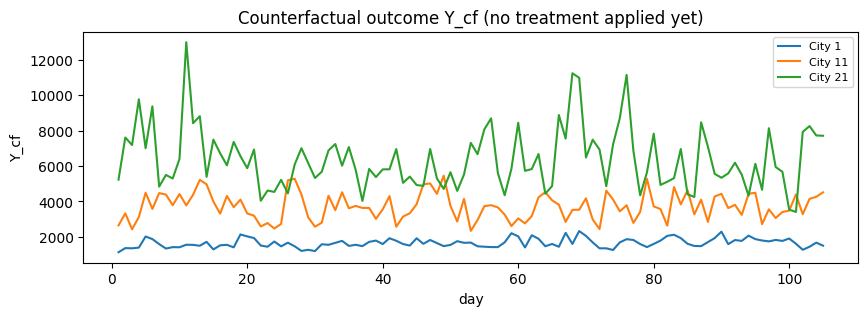

In [7]:
Y_cf = np.empty((TOTAL_DAYS, N_GEOS))
for i, geo in enumerate(geo_names):
    noise = ar1_noise(TOTAL_DAYS, AUTOCORRELATION, seed=SEED + 100_000 + i)
    scale_i = np.sqrt(baselines.iloc[i] / mean_baseline)
    Y_cf[:, i] = baselines.iloc[i] * trend * season * np.exp(NOISE_LEVEL * scale_i * noise)

plt.figure(figsize=(10, 3))
for geo in example_geos:
    idx = geo_names.index(geo)
    plt.plot(t_seq, Y_cf[:, idx], label=geo)
plt.title("Counterfactual outcome Y_cf (no treatment applied yet)")
plt.xlabel("day")
plt.ylabel("Y_cf")
plt.legend(fontsize=8)
plt.show()

## 7. Apply the treatment effect

In the post-period only (`date > PRE_DAYS`), the treated geo's *observed* outcome is
inflated by a constant multiplicative lift: `Y = Y_cf * (1 + effect_pct)`. Every other
geo, and the treated geo's pre-period, are untouched (`Y = Y_cf`).

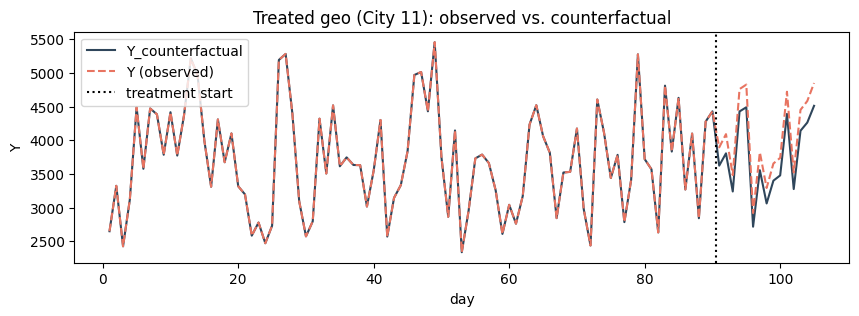

In [8]:
Y = Y_cf.copy()
post_mask = t_seq > PRE_DAYS
Y[post_mask, treated_idx] = Y_cf[post_mask, treated_idx] * (1 + EFFECT_PCT)

plt.figure(figsize=(10, 3))
plt.plot(t_seq, Y_cf[:, treated_idx], label="Y_counterfactual", color="#2f465b")
plt.plot(t_seq, Y[:, treated_idx], label="Y (observed)", color="#E87461", linestyle="--")
plt.axvline(PRE_DAYS + 0.5, color="black", linestyle=":", label="treatment start")
plt.title(f"Treated geo ({treated_name}): observed vs. counterfactual")
plt.xlabel("day")
plt.ylabel("Y")
plt.legend()
plt.show()

## 8. Wrap it all into one function

Now that we've seen every piece, here's a single `generate_panel(...)` function that
reproduces steps 1-7 for an arbitrary set of parameters and returns a long-format
DataFrame (`geo`, `date`, `Y`, `Y_counterfactual`, `treated`) — the same canonical
schema used everywhere else in this study.

In [9]:
def draw_baselines(n_geos, baseline_mean, baseline_spread, seed):
    local_rng = np.random.default_rng(seed)
    meanlog = np.log(baseline_mean) - baseline_spread**2 / 2
    draws = local_rng.lognormal(mean=meanlog, sigma=baseline_spread, size=n_geos)
    draws = np.sort(draws)
    names = [f"City {i + 1}" for i in range(n_geos)]
    return pd.Series(draws, index=names)


def select_treated(baselines, n_treated):
    median_val = baselines.median()
    diffs = (baselines - median_val).abs()
    treated_names = diffs.sort_values(kind="stable").index[:n_treated].tolist()
    treated_idx = [baselines.index.get_loc(name) for name in treated_names]
    return treated_names, treated_idx


def generate_panel(
    baselines, treated_idx, effect_pct, total_days, pre_days,
    trend_slope, seasonality_amplitude, dow_profile,
    autocorrelation, noise_level, seed, noise_baselines=None,
):
    """Generate one panel of synthetic geo-level time series.

    Y_cf[i,t] = baseline_i * trend_t * season_t * exp(noise_level * scale_i * ar_noise[i,t])
    scale_i = sqrt(noise_baselines_i / mean(noise_baselines))
    Treatment (post-period, treated geos only): Y[i,t] = Y_cf[i,t] * (1 + effect_pct)
    """
    local_rng = np.random.default_rng(seed)
    if noise_baselines is None:
        noise_baselines = baselines
    mean_baseline = noise_baselines.mean()

    geo_names = baselines.index.tolist()
    n_geos = len(geo_names)
    t_seq = np.arange(1, total_days + 1)

    trend = 1 + trend_slope * t_seq
    dow_idx = (t_seq - 1) % 7
    season = 1 + seasonality_amplitude * np.array(dow_profile)[dow_idx]

    Y_cf = np.empty((total_days, n_geos))
    Y = np.empty((total_days, n_geos))

    for i, geo in enumerate(geo_names):
        innovations = local_rng.standard_normal(total_days)
        noise = np.empty(total_days)
        noise[0] = innovations[0]
        for t in range(1, total_days):
            noise[t] = autocorrelation * noise[t - 1] + innovations[t]

        scale_i = np.sqrt(noise_baselines.iloc[i] / mean_baseline)
        Y_cf[:, i] = baselines.iloc[i] * trend * season * np.exp(noise_level * scale_i * noise)
        Y[:, i] = Y_cf[:, i]

    post_mask = t_seq > pre_days
    for idx in treated_idx:
        Y[post_mask, idx] = Y_cf[post_mask, idx] * (1 + effect_pct)

    df = pd.DataFrame({
        "geo": np.repeat(geo_names, total_days),
        "date": np.tile(t_seq, n_geos),
        "Y": Y.T.flatten(),
        "Y_counterfactual": Y_cf.T.flatten(),
    })
    treated_names = {geo_names[i] for i in treated_idx}
    df["treated"] = df["geo"].isin(treated_names)
    return df


baselines_check = draw_baselines(N_GEOS, BASELINE_MEAN, BASELINE_SPREAD, seed=SEED)
treated_names_check, treated_idx_check = select_treated(baselines_check, n_treated=1)
df_check = generate_panel(
    baselines=baselines_check, treated_idx=treated_idx_check, effect_pct=EFFECT_PCT,
    total_days=TOTAL_DAYS, pre_days=PRE_DAYS, trend_slope=TREND_SLOPE,
    seasonality_amplitude=SEASONALITY_AMPLITUDE, dow_profile=DOW_PROFILE,
    autocorrelation=AUTOCORRELATION, noise_level=NOISE_LEVEL, seed=SEED + 100_000,
)
print(f"treated: {treated_names_check}")
df_check.head()

treated: ['City 11']


,geo,date,Y,Y_counterfactual,treated
0,City 1,1,1129.195894,1129.195894,False
1,City 1,2,1361.912552,1361.912552,False
2,City 1,3,1350.630562,1350.630562,False
3,City 1,4,1389.772123,1389.772123,False
4,City 1,5,2017.758727,2017.758727,False


## 9. The four stress-test scenarios (A1-A4)

The study stress-tests each tool against four scenarios, each a small override on top
of the defaults above:

| Scenario | Name | Override |
|---|---|---|
| A1 | Textbook | none (baseline) |
| A2 | Outlier (5x) | treated geo's baseline inflated 5x *after* being picked — tests a convex-hull violation |
| A3 | Small donor pool | 9 control geos instead of 20 |
| A4 | Short pre-treatment | 45 total days / 30 pre-period instead of 105 / 90 |

For A2, note that the noise-scaling baseline is captured **before** the outlier
inflation, so the treated geo becomes an outlier in *level* without also becoming
extra noisy — isolating the effect of size alone.

In [10]:
DEFAULTS = dict(
    n_treated=1, n_control=20, baseline_mean=BASELINE_MEAN, baseline_spread=BASELINE_SPREAD,
    trend_slope=TREND_SLOPE, seasonality_amplitude=SEASONALITY_AMPLITUDE, dow_profile=DOW_PROFILE,
    autocorrelation=AUTOCORRELATION, noise_level=NOISE_LEVEL, outlier_multiplier=5.0,
    total_days=TOTAL_DAYS, pre_days=PRE_DAYS,
)

SCENARIOS = {
    "A1": {},
    "A2": {"outlier": True},
    "A3": {"n_control": 9},
    "A4": {"total_days": 45, "pre_days": 30},
}

SCENARIO_LABELS = {
    "A1": "A1: Textbook",
    "A2": "A2: Outlier (5x)",
    "A3": "A3: Small donor pool",
    "A4": "A4: Short pre-treatment",
}


def generate_scenario_panel(scenario_id, effect_pct=EFFECT_PCT, seed=SEED):
    overrides = SCENARIOS[scenario_id]
    params = {**DEFAULTS, **overrides}
    n_geos = params["n_treated"] + params["n_control"]
    is_outlier = bool(overrides.get("outlier", False))

    baselines = draw_baselines(n_geos, params["baseline_mean"], params["baseline_spread"], seed=seed)
    treated_names, treated_idx = select_treated(baselines, params["n_treated"])

    # Keep pre-inflation baselines for noise scaling so A2's outlier inflation
    # doesn't also amplify noise amplitude for the treated geo.
    noise_baselines = baselines.copy()
    if is_outlier:
        for idx in treated_idx:
            baselines.iloc[idx] *= params["outlier_multiplier"]

    df = generate_panel(
        baselines=baselines, treated_idx=treated_idx, effect_pct=effect_pct,
        total_days=params["total_days"], pre_days=params["pre_days"],
        trend_slope=params["trend_slope"], seasonality_amplitude=params["seasonality_amplitude"],
        dow_profile=params["dow_profile"], autocorrelation=params["autocorrelation"],
        noise_level=params["noise_level"], noise_baselines=noise_baselines, seed=seed + 100_000,
    )
    meta = {
        "scenario": scenario_id,
        "treated_units": treated_names,
        "treatment_start": params["pre_days"] + 1,
        "treatment_end": params["total_days"],
        "effect_pct": effect_pct,
    }
    return df, meta


panels = {}
for scenario_id in SCENARIOS:
    df, meta = generate_scenario_panel(scenario_id)
    panels[scenario_id] = (df, meta)
    print(f"{scenario_id}: {df['geo'].nunique()} geos, {df['date'].max()} days, "
          f"treated={meta['treated_units']}, treatment_start={meta['treatment_start']}")

A1: 21 geos, 105 days, treated=['City 11'], treatment_start=91
A2: 21 geos, 105 days, treated=['City 11'], treatment_start=91
A3: 10 geos, 105 days, treated=['City 5'], treatment_start=91
A4: 21 geos, 45 days, treated=['City 11'], treatment_start=31


### Plot all four scenario panels

Same visual language as the tool-comparison notebook: control geos in light gray,
control average in navy, the treated geo in coral, treatment start as a dashed line.

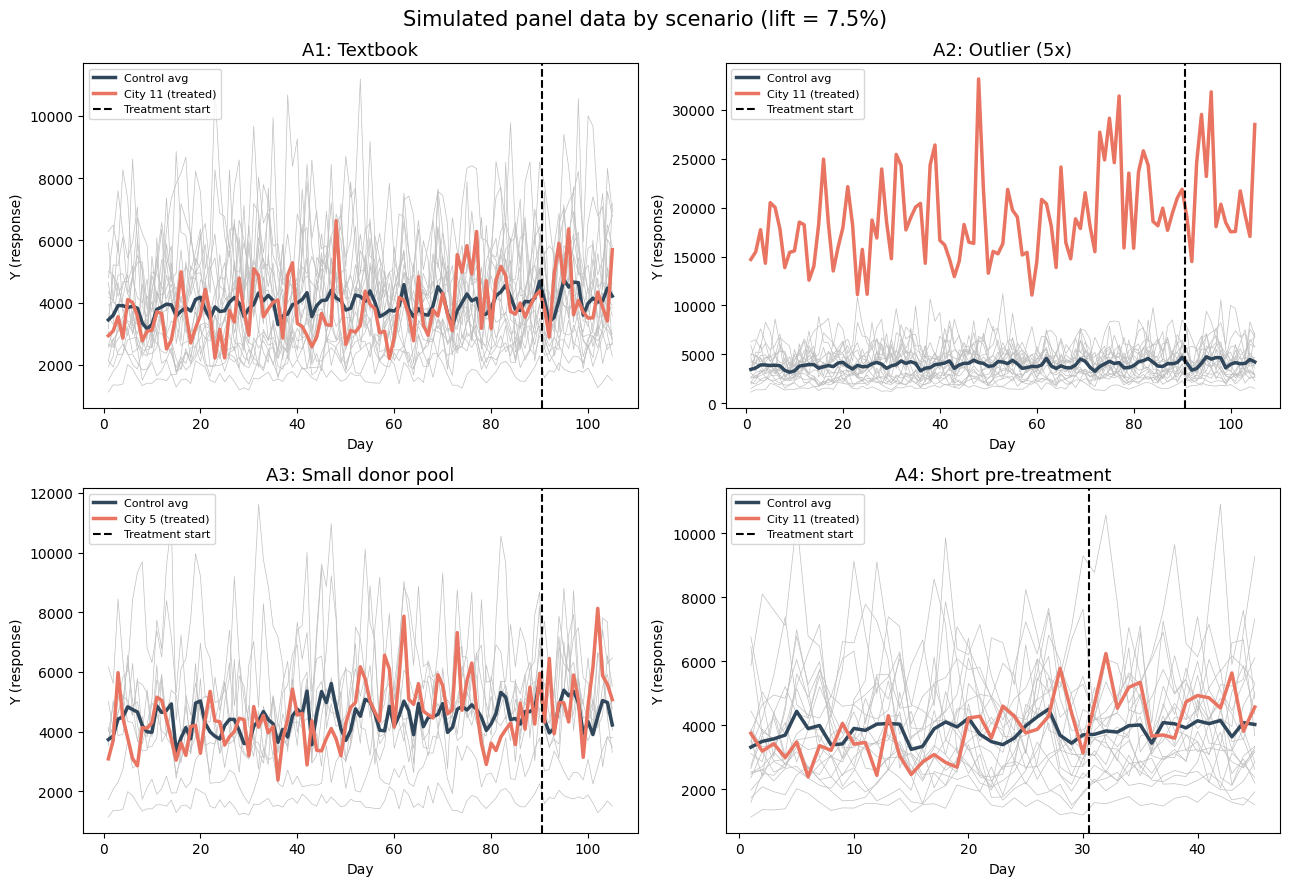

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, scenario_id in zip(axes.flat, SCENARIOS):
    df, meta = panels[scenario_id]
    treated_geo = meta["treated_units"][0]
    control_geos = [g for g in df["geo"].unique() if g != treated_geo]

    for g in control_geos:
        gd = df[df["geo"] == g].sort_values("date")
        ax.plot(gd["date"], gd["Y"], color="#c0c0c0", linewidth=0.5)

    ctrl_avg = df[df["geo"].isin(control_geos)].groupby("date")["Y"].mean()
    ax.plot(ctrl_avg.index, ctrl_avg.values, color="#2f465b", linewidth=2.5, label="Control avg")

    td = df[df["geo"] == treated_geo].sort_values("date")
    ax.plot(td["date"], td["Y"], color="#E87461", linewidth=2.5, label=f"{treated_geo} (treated)")

    ax.axvline(meta["treatment_start"] - 0.5, color="black", linestyle="--", linewidth=1.5, label="Treatment start")
    ax.set_title(SCENARIO_LABELS[scenario_id], fontsize=13)
    ax.set_xlabel("Day")
    ax.set_ylabel("Y (response)")
    ax.legend(loc="upper left", fontsize=8)

fig.suptitle(f"Simulated panel data by scenario (lift = {EFFECT_PCT:.1%})", fontsize=15)
fig.tight_layout()
plt.show()

## Recap

Every panel in this study is built from five ingredients, each written out above:

1. **Log-normal geo baselines** — different geos have different scale.
2. **Median-closest treated-geo selection** — the treated unit is typical, not extreme
   (unless a scenario deliberately overrides this, like A2).
3. **Shared linear trend + weekly seasonality** — structure every geo shares.
4. **Per-geo AR(1) multiplicative noise**, scaled by `sqrt(baseline_i / mean)` —
   idiosyncratic, autocorrelated variation.
5. **A constant multiplicative post-period lift on the treated geo** — the ground truth
   we're trying to recover.

This is a from-scratch teaching copy for exploration — it doesn't need to bit-match R's
RNG, only to reproduce the same statistical structure. The reusable, imported version
used elsewhere in this repo is `src/python/panel_dgp.py`; the canonical version that
produced the study's committed results is `src/R/generate_panels.R`.